# Re-Deriving the Branching Ratio 
...of eta -> mu+ mu- gamma, from the 1980 analysis paper  


**Author**: Michael Peters  

### Define constants and data

In [18]:
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from tabulate import tabulate
import math

# Alternate constants (from pdg)
alpha_ = 1. / 137. # m_Z mass scale
m_eta_pdg = 0.547862  # GeV/c^2
m_eta=.54867  # digitized from paper
m_mu=.1056583745  # from pdg
br_eta2gg=.3941  # from pdg
prefactor = (2 * alpha) / (3 * np.pi) * br_eta2gg

In [19]:
# Digitized data from plot in paper
x = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
              0.18911, 0.2188])
y = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
              3.21721, 2.55531])
ybar = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
        3.23895]  # upper error bars
yerr = np.subtract(ybar, y)  # y errors

# Parameters from paper
LAMBDA0 = [.72, .09]  # from paper; [value, uncertainty]
# K is a nuisance parameter that is only used to fit a value of Lambda to the data.
# Once Lambda is fit, K does not go into the integral which calculates the BR.
K0 = .9089376019880376  # digitized from Fig. 2; [value]



### Define FormFactor class

In [20]:
class FormFactor:
    def __init__(self, alpha=.0074, m_eta=.54867, m_mu=.1056583745, br_eta2gg=.3941, Lambda0=LAMBDA0, K0=K0):
        self.alpha = alpha
        self.m_eta = m_eta
        self.m_mu = m_mu
        self.br_eta2gg = br_eta2gg
        self.q2_min = (2 * self.m_mu)**2
        self.q2_max = self.m_eta**2
        self.prefactor = (2 * self.alpha) / (3 * np.pi) * self.br_eta2gg
        self.Lambda0 = Lambda0
        self.K0 = K0
    

    # =============================================================================


    def F(self, x, Lambda, K):
        """Form factor of the eta meson in the pole approximation. Eqn. 5 from the
        paper.

        Args:
        x (param, float) : m^2_{mu,mu}
        K (float) : coefficient accounting for experimental normalization
                    uncertainty
        Lambda (float) : pole approximation coefficient

        Returns:
        Form factor F(m^2_{mu,mu}; 0)
        """
        return K * (1.0 - x / Lambda**2)**(-1)


    # =============================================================================


    def F2(self, x, Lambda, K):
        """Form factor squared of the eta meson. Eqn. from Fig. 2 caption.

        Args:
        x (param, float) : m^2_{mu,mu}
        K (float) : coefficient accounting for experimental normalization
                    uncertainty.
        Lambda (float) : pole approximation coefficient

        Returns:
        Form factor F(m^2_{mu,mu}; 0)
        """
        return K * (1.0 - x / (Lambda**2))**(-2)


    # =============================================================================


    def fit(self, x, y, yerr=None, fit_Lambda=True, fit_K=True):
        """Fit wrapper for scipy's curve_fit() which allows for choice of free
        parameters.

        Args:
            x (list): x values from data in plot
            y (list): y values from data in plot
            yerr (np.array, optional): y error values from data in plot. Defaults 
                to None.
            fit_Lambda (bool, optional): _description_. Defaults to True.
            fit_K (bool, optional): _description_. Defaults to True.

        Returns:
            dict (string, float): Lambda and K fit results, including errors.
        """
        # For all fixed values.
        if not fit_Lambda and not fit_K:
            return {'Lambda': self.Lambda0[0], 
                    'Lambda_err': self.Lambda0[1],
                    'K': K0, 
                    'K_err': 0.0}
        if fit_Lambda and fit_K:
            def fnc(x, Lambda, K): return self.F2(x, Lambda, K)
            bounds = ([0.0, 0.0], [np.inf, np.inf])
        elif fit_Lambda and not fit_K:
            def fnc(x, Lambda): return self.F2(x, Lambda, K0)
            bounds = ([0.0], [np.inf])
        elif not fit_Lambda and fit_K:
            def fnc(x, K): return self.F2(x, self.Lambda0[0], K)
            bounds = ([0.0], [np.inf])

        # Ensure all data is numpy array
        popt, pcov = curve_fit(fnc, np.array(x), np.array(y), sigma=np.array(yerr), 
                               absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        # Convert to float values
        popt = [float(v) for v in popt]
        perr = [float(v) for v in perr]

        result = {}
        idx = 0
        if fit_Lambda:
            result['Lambda'] = popt[idx]
            result['Lambda_err'] = perr[idx]
            idx += 1
        else:
            result['Lambda'] = self.Lambda0[0]
            result['Lambda_err'] = self.Lambda0[1]
        if fit_K:
            result['K'] = popt[idx]
            result['K_err'] = perr[idx]
            idx += 1
        else:
            result['K'] = K0
            result['K_err'] = 0.0

        return result
    

    # =============================================================================


    def integrand(self, q2, Lambda):
        """Integrand of the eta form factor integral over q2. Eqn. 4 from the
        paper.

        Args:
        q2 (param, float): m^2_{mu,mu}
        Lambda (float): pole approximation coefficient

        Returns:
        float: integrand of the eta form factor integral over q2
        """
        # Kinematic limits
        if q2 < self.q2_min or q2 > self.q2_max:
            return 0.0

        term1 = (1 - q2 / self.m_eta**2)**3
        term2 = (1 + 2 * self.m_mu**2 / q2)
        term3 = np.sqrt(1 - 4 * self.m_mu**2 / q2)
        term4 = abs(self.F2(q2, Lambda, K=1.0))
        return term1 * term2 * term3 * term4 / q2
    

    # =============================================================================


    def integrate(self, Lambda, bounds=None):
        """Calculate form factor integral.

        Args:
        Lambda (float): Parameter value
        bounds (list (float, float)): (Optional) Custom bounds of integration.
            Default bounds of integration are [self.q2_min, self.q2_max].

        Returns: 
        (float, float): integral value and its numerical uncertainty
        """
        if bounds is None: bounds = [self.q2_min, self.q2_max]

        # Pass points of possible divergence into `quad`, which then handles any
        # difficulties in convergence.
        points = []
        if bounds[0] < Lambda**2 < bounds[1]: points.append(Lambda**2)

        return integrate.quad(lambda q2: self.integrand(q2, Lambda),
                              bounds[0], bounds[1], points=points)
        # return integrate.quad(lambda q2: self.integrand(q2, Lambda),
        #                       bounds[0], bounds[1])
    

    # =============================================================================


    def branching_ratio(self, Lambda, bounds=None):
        """Calculate the branching ratio.

        Args:
            Lambda (float): Lambda parameter value

        Returns:
            list (float, float): List of branching ratio and its uncertainty value
        """
        int_val, _ = self.integrate(Lambda, bounds=bounds)
        return self.prefactor * int_val


In [21]:
# ff = FormFactor(alpha=alpha_mz, m_eta=m_eta_pdg)
ff = FormFactor()

In [22]:
fits = []
fit_Lambda = [True, False]
fit_K = [True, False]
table = []

for i in range(2):
    for j in range(2):
        fit = {'fit_Lambda': fit_Lambda[i], 'fit_K': fit_K[j]}
        fit.update(ff.fit(x, y, yerr, fit_Lambda=fit_Lambda[i], fit_K=fit_K[j]))
        fits.append(fit)

for fit in fits:
    table.append((fit['fit_Lambda'], fit['fit_K'], 
                  f"{fit['Lambda']:.2f}", f"{fit['Lambda_err']:.2f}", 
                  f"{fit['K']:.2f}", f"{fit['K_err']:.2f}"))

headers = ['fit Λ', 'fit K', 'Λ', 'ΔΛ', 'K', 'ΔK']
print(tabulate(table, headers, tablefmt="github"))

| fit Λ   | fit K   |    Λ |   ΔΛ |    K |   ΔK |
|---------|---------|------|------|------|------|
| True    | True    | 0.7  | 0.05 | 0.87 | 0.11 |
| True    | False   | 0.72 | 0.03 | 0.91 | 0    |
| False   | True    | 0.72 | 0.09 | 0.9  | 0.05 |
| False   | False   | 0.72 | 0.09 | 0.91 | 0    |


In [23]:
table = []
for fit in fits:
    int_val, int_err = ff.integrate(fit['Lambda'])
    br = ff.branching_ratio(fit['Lambda'])

    print(f"fit Lambda = {fit['fit_Lambda']}, fit K = {fit['fit_K']}:")
    print(f"integral = {int_val:.3f} ± {int_err:.0e}")
    print(f"BR = {br * 1e4:.2f}e-4\n")

    table.append((
        str(fit['fit_Lambda']),
        str(fit['fit_K']),
        f"{br * 1e4:.2f}e-4"
    ))

headers = ['fit Λ', 'fit K', 'BR']
print(tabulate(table, headers, tablefmt="github"))

fit Lambda = True, fit K = True:
integral = 0.550 ± 7e-09
BR = 3.40e-4

fit Lambda = True, fit K = False:
integral = 0.535 ± 7e-09
BR = 3.31e-4

fit Lambda = False, fit K = True:
integral = 0.534 ± 7e-09
BR = 3.30e-4

fit Lambda = False, fit K = False:
integral = 0.534 ± 7e-09
BR = 3.30e-4

| fit Λ   | fit K   |       BR |
|---------|---------|----------|
| True    | True    | 0.00034  |
| True    | False   | 0.000331 |
| False   | True    | 0.00033  |
| False   | False   | 0.00033  |


### Plot Fits

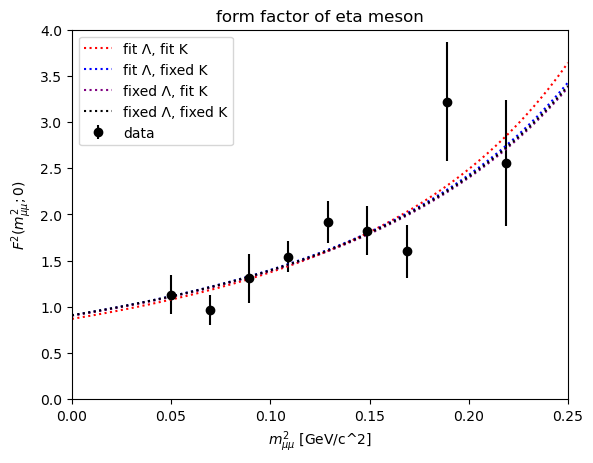

In [24]:
# Plot data with error bars and the fitted curve
plt.errorbar(x, y, yerr=yerr, fmt='o', color='black', label='data')
xx = np.linspace(0, 0.25, 400)
plt.plot(xx, ff.F2(xx, fits[0]['Lambda'], fits[0]['K']), ':', color='red',
            label=f"fit Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[1]['Lambda'], fits[1]['K']), ':', color='blue',
            label=f"fit Λ, fixed K")
plt.plot(xx, ff.F2(xx, fits[2]['Lambda'], fits[2]['K']), ':', color='purple',
            label=f"fixed Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[3]['Lambda'], fits[3]['K']), ':', color='black',
            label=f"fixed Λ, fixed K")
plt.legend()
plt.xlim(0, .25)
plt.ylim(0, 4)
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV/c^2]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")
plt.title("form factor of eta meson")
plt.show()


These fits are all in very close agreement, deviating most significantly at the tail end (which is expected given the greater variance and fewer data points).

## Uncertainty Propagation

### Method I: Numerical Propagation

Here, we sample `n` values of Λ normally distributed about its mean, with standard deviation $\sigma_\Lambda$.

For each Λ sampled, we compute the branching ratio. We then collect all these branching ratio values and find their mean and standard deviation.

In [25]:
ff = FormFactor()
n = 10000
Lambdas = np.random.normal(LAMBDA0[0], LAMBDA0[1], n)

br_values = []
for Lambda in Lambdas:
    int_val, int_err = ff.integrate(Lambda)
    br = ff.branching_ratio(Lambda)
    br_values.append(br)

br_values = np.array(br_values)
br_mean = np.mean(br_values)
br_unc  = math.sqrt(np.std(br_values)**2 + int_err**2)
print(f"BR = ({br_mean * 10000.:.2f} ± {br_unc * 10000.:.2f})e-4")

/var/folders/vx/cy_c9gk53x7b6f1k5brcs4r40000gn/T/ipykernel_33994/1340551030.py:160: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return integrate.quad(lambda q2: self.integrand(q2, Lambda),


BR = (3.47 ± 0.62)e-4


The result is in agreement with previous calculations (somewhat too high).

---

### Method II: $\pm\sigma$ Difference
Calculate branching ratio from $\Lambda+\sigma_\Lambda$ and $\Lambda-\sigma_\Lambda$, find the difference, then divide by 2. This method is quick and works well if the lambda uncertainty is smooth and approximately linear.

In [ ]:
# TODO: fix uncertainty calculation, chi2 fit num solve for best values of m and alpha from two equations (Br and deltaBR)
# if fit can't go to zero, minimize chi2, color plot axes m and alpha, grid scan, calculate chi2 for each combination of values
# then you can use some fitter if you want to find the minimum, will prolly be a valley/line and we choose within it
# you can delete most of the methods below since they really aren't correct.
# also you should relisten to the middle/last part of the voice recording from the 23 January meeting with Phil where Phil explained all this
# also take a look at the picture I took from Phil's notebook where he sketches out what to do.
# phil confirmed method II is correct way to do uncertainty calc

# Define Lambda values
Lambda_p = .81
Lambda_m = .63

# Not worrying about uncertainty calculation right now
ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)

br_p = ff_p.branching_ratio(Lambda_p)
br_m = ff_m.branching_ratio(Lambda_m)

# Print values
print(f"BR+ = {br_p * 10000.:.2f}e-4")
print(f"BR- = {br_m * 10000.:.2f}e-4\n")

# Find difference
br_unc = abs((br_p - br_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

BR+ = 3.00e-4
BR- = 3.88e-4

BR uncertainty = 0.44e-4



### Method III: Central Finite Difference

But supposing lambda uncertainty is not linear, it would be better to take a much smaller step in either direction of the current uncertainty and use that to find a more accurate slope, which can then be used to calculate the branching ratio uncertainty.

There is an alternative, numerical way, to approximate the uncertainty. The idea is to see how sensitive $I(\Lambda)=\int I(q^2,\Lambda),dq^2$ is to changes in $\Lambda$, then propagate that uncertainty to the branching ratio $BR$.

We want $\dfrac{dI}{d\Lambda}$ at $\Lambda=\Lambda_0$, so let's approximate it numerically. We first find the central finite difference

$$
\frac{dI}{d\Lambda}\Big|_{\Lambda_0}\approx\frac{I(\Lambda_0+\varepsilon)-I(\Lambda_0-\varepsilon)}{2\varepsilon}.
$$

We can then propagate $\Lambda$’s uncertainty $\sigma_\Lambda$ linearly:

$$
\sigma_{BR,\Lambda}=P\left|\frac{dI}{d\Lambda}\right|\sigma_\Lambda,
$$

then combine that with the numeric integration uncertainty (on $I$) in quadrature:

$$
\sigma_{BR}=\sqrt{(P\cdot\sigma_{I,\text{num}})^2 + (P\cdot dI/d\Lambda\cdot\sigma_\Lambda)^2 }.
$$


In [27]:
# First, determine appropriate step value
for factor in [1000,100,50,20,10,5,2,1,0.7,0.6]:
    eps = LAMBDA0[1] / factor
    I_p, _ = ff.integrate(LAMBDA0[0] + eps)
    I_m, _ = ff.integrate(LAMBDA0[0] - eps)
    dI = (I_p - I_m) / (2*eps)
    print(f"factor={factor:.1f},\teps={eps:.2e},\tdI/dL={dI:.6e}")

factor=1000.0,	eps=9.00e-05,	dI/dL=-7.142719e-01
factor=100.0,	eps=9.00e-04,	dI/dL=-7.142785e-01
factor=50.0,	eps=1.80e-03,	dI/dL=-7.142985e-01
factor=20.0,	eps=4.50e-03,	dI/dL=-7.144390e-01
factor=10.0,	eps=9.00e-03,	dI/dL=-7.149410e-01
factor=5.0,	eps=1.80e-02,	dI/dL=-7.169568e-01
factor=2.0,	eps=4.50e-02,	dI/dL=-7.314189e-01
factor=1.0,	eps=9.00e-02,	dI/dL=-7.887791e-01
factor=0.7,	eps=1.29e-01,	dI/dL=-8.882820e-01
factor=0.6,	eps=1.50e-01,	dI/dL=-9.808376e-01


/var/folders/vx/cy_c9gk53x7b6f1k5brcs4r40000gn/T/ipykernel_33994/1340551030.py:160: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return integrate.quad(lambda q2: self.integrand(q2, Lambda),


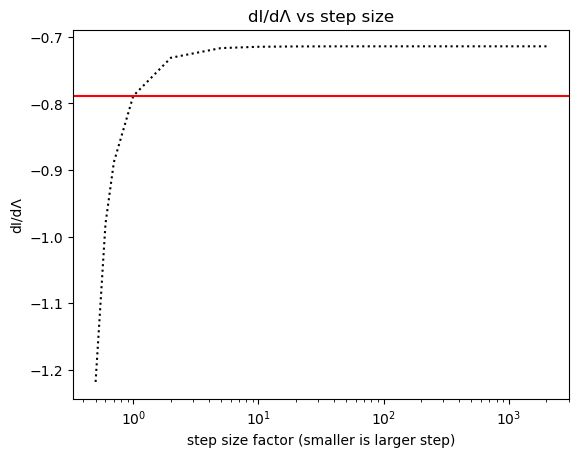

In [ ]:
# Plot the dependence of the integral on Lambda by step size
values = []
factors = [2000,1750,1500,1250,1000,750,500,250,100,50,20,10,5,2,1,0.7,0.6,0.5]

for factor in factors:
    eps = LAMBDA0[1] / factor
    I_p, _ = ff.integrate(LAMBDA0[0] + eps)
    I_m, _ = ff.integrate(LAMBDA0[0] - eps)
    dI = (I_p - I_m) / (2*eps)
    values.append(dI)

# Plot data with error bars and the fitted curve
plt.plot(factors, values, ':', color='black')
# Plot horizontal line at dI/dL for Lambda uncertainty from paper (0.09)
Ip_ref, _ = ff.integrate(LAMBDA0[0] + LAMBDA0[1])
Im_ref, _ = ff.integrate(LAMBDA0[0] - LAMBDA0[1])
dI_ref = (Ip_ref - Im_ref) / (2 * LAMBDA0[1])
plt.axhline(dI_ref, color='red', linestyle='-', label='ref')
plt.xlabel("step size factor (smaller is larger step)")
plt.ylabel("dI/dΛ")
plt.title("dI/dΛ vs step size")
plt.xscale('log')
plt.show()

In [29]:
# See how sensitive I(Lambda) is to Lambda uncertainty, then propagate that
# to BR uncertainty

# Use the best step value for epsilon
eps = LAMBDA0[1] / 100.0
# I at Lambda + eps
I_p, _ = ff.integrate(LAMBDA0[0] + eps)
# I at Lambda - eps
I_m, _ = ff.integrate(LAMBDA0[0] - eps)
# Central finite difference
dI = (I_p - I_m) / (2*eps)

br = ff.branching_ratio(LAMBDA0[0])

# Combine numeric and propagated uncertainties in quadrature
br_unc = np.sqrt((prefactor * dI * LAMBDA0[1])**2)

# Print result
print(f"\nAlternate calculation using dI/dΛ with ε = {eps:.2e}:")
print(f"BR = ({br * 10000.:.2f} ± {br_unc * 10000.:.2f})e-4\n")


Alternate calculation using dI/dΛ with ε = 9.00e-04:
BR = (3.30 ± 0.40)e-4



The result is pretty good.

---

### Method III: Analytical Propagation

Here, we get an explicit formula for the branching ratio 

$$BR(\Lambda) = P \int F(q^2, \Lambda)dq^2 = g(\Lambda).$$

The uncertainty can then be propagated analytically by

$$\sigma_{BR} = \left| \frac{dg}{d\Lambda} \right| \sigma_\Lambda.$$

In this case, the integral works out to

$$
g(\Lambda) = P \int^{q^2_{max}}_{q^2_{min}} \left( 1-\frac{q^2}{\Lambda^2} \right)^{-1} dq^2
= P \left. \Lambda^2 ln(\left|q^2-\Lambda^2\right|) \right|^{q^2_{max}}_{q^2_{min}}
$$

Plugging in $q^2_{min} = .0446$ and $q^2_{max} = .300$, we find

$$
g(\Lambda) =  -P\Lambda^{2} \left(\ln\left(\frac{1000000\Lambda^{2} - 300153}{1000000\Lambda^{2}}\right) - \ln\left(\frac{200000\Lambda^{2} - 8931}{200000\Lambda^{2}}\right)\right)
$$

Now we differentiate $g(\Lambda)$ w.r.t. $\Lambda$

$$
\left| \frac{dg}{d\Lambda} \right| \sigma_\Lambda = 
P \left( -2\Lambda \left(\ln\left(\frac{1000000\Lambda^{2} - 300153}{1000000\Lambda^{2}}\right) - \ln\left(\frac{200000\Lambda^{2} - 8931}{200000\Lambda^{2}}\right)\right) - \Lambda^{2} \left(\frac{1000000\Lambda^{2} \left(\frac{2}{\Lambda} - \frac{1000000\Lambda^{2} - 300153}{500000\Lambda^{3}}\right)}{1000000\Lambda^{2} - 300153} - \frac{200000\Lambda^{2} \left(\frac{2}{\Lambda} - \frac{200000\Lambda^{2} - 8931}{100000\Lambda^{3}}\right)}{200000\Lambda^{2} - 8931}\right) \right) \sigma_{\Lambda},
$$ 

and apply $\Lambda = .72$ and $\sigma_\Lambda = .09$ values to this. Apply the prefactor (found above), as well. The result is

$$\left| \frac{dg}{d\Lambda} \right|_{\Lambda_0 = .72} \sigma_\Lambda = \left| 0.0006104 \times -0.7286242445 \right| \times .09 = 4.00277015\times10^{-5} \approx 0.4\times10^{-4}.$$

This is exactly the uncertainty of the branching ratio from the paper! However, this is probably the wrong way to go about this. We cannot assume that just because the uncertainty only depends on $\sigma_\Lambda$ doesn't mean that we can ignore the other components of the integral for the purposes of calculating the branching ratio uncerainty. Probably. While it's tempting to look at this result and proclaim it works, it is (probably) not mathematically sound... Too bad.

---


### Method III: Analytical Propagation

Interestingly, we don't get the same result repeating the process for the fit function described in Fig. 2.

Using the fit function described in Fig. 2 of the paper

$$
F(q^2) = \left( 1-\frac{q^2}{\Lambda^2} \right)^{-2}
$$

the integral works out to

$$
g(\Lambda) = P \int^{q^2_{max}}_{q^2_{min}} \left( 1-\frac{q^2}{\Lambda^2} \right)^{-2} dq^2
= P \left. \frac{\Lambda^2}{1-\frac{q^2}{\Lambda^2}} \right|^{q^2_{max}}_{q^2_{min}}
= \left. -P \frac{\Lambda^4}{q^2-\Lambda^2} \right|^{q^2_{max}}_{q^2_{min}}.
$$

Plugging in $q^2_{min} = .0446$ and $q^2_{max} = .300$, we find

$$g(\Lambda) = P \frac{5.11\times10^{10}\Lambda^4}{2.00\times10^{11}\Lambda^4 - 6.89\times10^{10}\Lambda^2 + 2.68\times10^9}$$

Now differentiate $g(\Lambda)$ w.r.t. $\Lambda$

$$
\left| \frac{dg}{d\Lambda} \right| \sigma_\Lambda = \left| -P\frac{5110\Lambda^{3} \left(3445\Lambda^{2} - 268\right)}{\left(10000\Lambda^{4} - 3445\Lambda^{2} + 134\right)^{2}} \right| \sigma_\Lambda,
$$ 

and apply $\Lambda = .72$ and $\sigma_\Lambda = .09$ values to this. Apply the prefactor (found above), as well. The result is

$$\left| \frac{dg}{d\Lambda} \right|_{\Lambda_0 = .72} \sigma_\Lambda = \left| 0.0006104 \times -2.699976124 \right| \times .09 = 1.483\times10^{-4},$$

which does not match the paper. The reason is because this $F^2(q^2)$ can only be applied in the context of calculating the branching ratio. Since the additional terms in the branching ratio calculation do not have any additional uncertainty (due to $\Lambda$), they do not factor into the uncertainty calculation. That's why the first attempt was successful and this was not.

---

## Reconstructing Paper

### Deriving mass of eta used in paper
Find the mass value needed to get a branching ratio of 3.1e-4 for fixed alpha = .0074.

|    Λ |   ΔΛ |   m_eta |      BR |
|------|------|---------|---------|
| 0.72 | 0.09 | 0.53855 | 0.00031 |


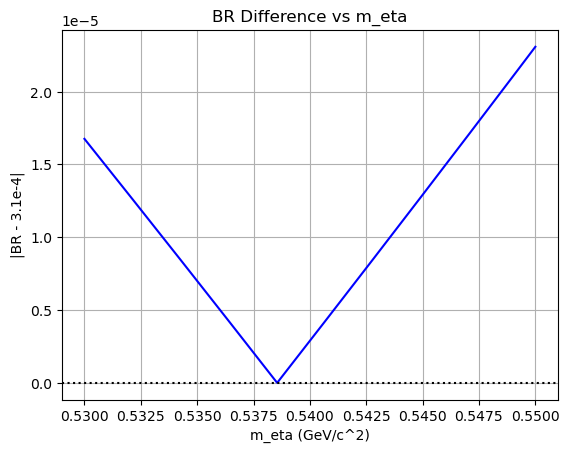

In [30]:
br_target = 3.1e-4
table = []
values = []

for m_eta in np.arange(.53, .55, .00001):
    ff_temp = FormFactor(m_eta=m_eta)
    br_temp = ff_temp.branching_ratio(LAMBDA0[0])
    diff = abs(br_temp - br_target)
    values.append((m_eta, br_temp, diff))

# Find minimum
values = np.array(values)
# : = all rows; 2 = third column (diff)
min_idx = np.argmin(values[:,2])
# min_idx = row, 0 = first column (m_eta)
m_eta_best = values[min_idx,0]
# 1 = second column (br)
br_best = values[min_idx,1]

table.append([LAMBDA0[0], LAMBDA0[1], f"{m_eta_best:.6f}", f"{br_best * 1e4:.2f}e-4"])
# Print table
headers = ['Λ', 'ΔΛ', 'm_eta', 'BR']
print(tabulate(table, headers, tablefmt="github"))

# Plot
plt.plot(values[:,0], values[:,2], color='blue', linestyle='-')
plt.axhline(0, color='black', linestyle=':')
plt.xlabel('m_eta (GeV/c^2)')
plt.ylabel('|BR - 3.1e-4|')
plt.title('BR Difference vs m_eta')
plt.grid()
plt.show()


To propagate uncertainty is to determine how the uncertainty from an input value affects the final result. For example, the eta form factor depends on Λ, i.e.

$$BR = F(\Lambda)$$

Λ has an uncertainty $\sigma_\Lambda$ which gives $F(\Lambda)$ some uncertainty, as well.

Uncertainty can be propagated (1) numerically or (2) analytically.

### Deriving alpha used in paper
Finds the alpha value needed to get exactly a branching ratio of 3.1e-4 for fixed m_eta = .54867.

In [31]:
ff = FormFactor()
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / br_eta2gg
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))


|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00674 |
| True    |  False  | 0.00692 |
| False   |  True   | 0.00694 |
| False   |  False  | 0.00694 |


In [32]:
# Repeat using m_eta derived above (.53855), just to confirm alpha values
ff = FormFactor(m_eta=m_eta_best)
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / br_eta2gg
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))

|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00719 |
| True    |  False  | 0.00738 |
| False   |  True   | 0.0074  |
| False   |  False  | 0.0074  |


### Plot of (br uncertainty / br) vs q2 max

br_val = -0.0, br_unc = 0.0 at q2_max = 0.04409999999999999
br_val = 4.498981268656783e-07, br_unc = 2.1342133040093553e-08 at q2_max = 0.045099999999999994
br_val = 2.5569950121725926e-06, br_unc = 1.2305650127731094e-07 at q2_max = 0.046099999999999995
br_val = 5.471814113201737e-06, br_unc = 2.670672437159194e-07 at q2_max = 0.047099999999999996
br_val = 8.902981470460807e-06, br_unc = 4.405636859974258e-07 at q2_max = 0.0481
br_val = 1.2700627555130253e-05, br_unc = 6.37025878141699e-07 at q2_max = 0.0491
br_val = 1.6768495949349852e-05, br_unc = 8.522449884890471e-07 at q2_max = 0.0501
br_val = 2.103851620925501e-05, br_unc = 1.0831994480798546e-06 at q2_max = 0.0511
br_val = 2.5459868435971455e-05, br_unc = 1.3275822454266137e-06 at q2_max = 0.0521
br_val = 2.999328129710775e-05, br_unc = 1.5835595047274997e-06 at q2_max = 0.0531
br_val = 3.460768486210658e-05, br_unc = 1.8496314122892055e-06 at q2_max = 0.0541
br_val = 3.927808046665002e-05, br_unc = 2.1245451667811337e-06 at q2

/var/folders/vx/cy_c9gk53x7b6f1k5brcs4r40000gn/T/ipykernel_33994/3949189330.py:29: RuntimeWarning: invalid value encountered in scalar divide
  values.append([q2_max, br_unc / br_val, br_val, br_unc])


br_val = 0.0003059483217650319, br_unc = 3.5707736835311125e-05 at q2_max = 0.21610000000000015
br_val = 0.0003061197975486703, br_unc = 3.5769270379920604e-05 at q2_max = 0.21710000000000015
br_val = 0.00030628561716025085, br_unc = 3.582924767231113e-05 at q2_max = 0.21810000000000015
br_val = 0.0003064459046298759, br_unc = 3.588768468236986e-05 at q2_max = 0.21910000000000016
br_val = 0.00030660078246429, br_unc = 3.594459760315491e-05 at q2_max = 0.22010000000000016
br_val = 0.00030675037166505475, br_unc = 3.600000285044751e-05 at q2_max = 0.22110000000000016
br_val = 0.00030689479174609695, br_unc = 3.605391706215917e-05 at q2_max = 0.22210000000000016
br_val = 0.0003070341607506304, br_unc = 3.610635709755523e-05 at q2_max = 0.22310000000000016
br_val = 0.00030716859526746913, br_unc = 3.61573400366266e-05 at q2_max = 0.22410000000000016
br_val = 0.00030729821044672457, br_unc = 3.620688317904587e-05 at q2_max = 0.22510000000000016
br_val = 0.00030742312001489914, br_unc = 3.62

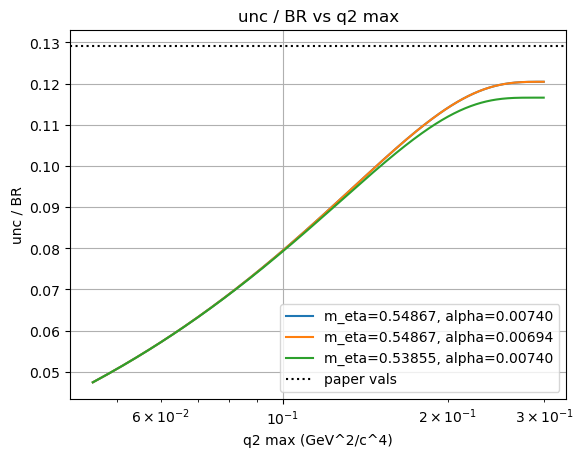

In [33]:
# Plot (uncertainty / br) vs q2 max for fixed m_eta, fixed alpha; fixed m_eta, fit alpha; fit m_eta, fixed alpha
# q2 max values from .210 to .54867
# q2_max_values = np.arange(0.210, 0.54867, 0.001)
q2_max_values = np.arange(0.210**2, 0.3, 0.001)
# Define m_eta and alpha to use for looping
pairs = [[.54867, .0074], [.54867, .00694], [.53855, .0074]]  # skip fit, fit case
eps = LAMBDA0[1] / 100.0

for pair in pairs:
    m_eta, alpha = pair
    values = [] # [q2_max, br_unc / br]
    ff_temp = FormFactor(m_eta=m_eta, alpha=alpha)
    prefactor = ff_temp.prefactor

    # Sample over q2 max values and calculate br_unc / br
    for q2_max in q2_max_values:
        bounds = [ff_temp.q2_min, q2_max]

        I_p, _ = ff_temp.integrate(LAMBDA0[0] + eps, bounds=bounds)
        I_m, _ = ff_temp.integrate(LAMBDA0[0] - eps, bounds=bounds)
        dI = (I_p - I_m) / (2 * eps)
        
        br_val = ff_temp.branching_ratio(Lambda=LAMBDA0[0], bounds=bounds)
        
        # Combine numeric and propagated uncertainties in quadrature
        br_unc = np.abs((prefactor * dI * LAMBDA0[1]))
        
        print(f'br_val = {br_val}, br_unc = {br_unc} at q2_max = {q2_max}')  # debug
        values.append([q2_max, br_unc / br_val, br_val, br_unc])

    # Create plot from values
    values = np.array(values)
    plt.plot(values[:,0], values[:,1], label=f"m_eta={m_eta:.5f}, alpha={alpha:.5f}")
    plt.legend()  # debug
    # plt.show()  # debug

# Plot actual line for reference (br = 3.1e-4, unc = 0.4e-5)
plt.axhline(4e-5 / 3.1e-4, color='black', linestyle=':', label='paper vals')
# plt.axhline(3.7e-5 / 3.1e-4, color='red', linestyle='--', label='lower unc')
# plt.yscale('log')
plt.xlabel('q2 max (GeV^2/c^4)')
plt.ylabel('unc / BR')
plt.title('unc / BR vs q2 max')
plt.grid()
plt.legend()
plt.xscale('log')
plt.show()

Here’s an intuitive, step-by-step explanation of the central finite difference approach for the branching-ratio uncertainty, and how it relates to the “Λ ± σΛ” method.

What we need: ( $BR(\Lambda) = P \cdot I(\Lambda)$ ) where ($P$) is your prefactor and ($I(\Lambda)$) is the integral over ($q^2$). The uncertainty on ($BR$) from Λ comes from how sensitive ($I(\Lambda)$) is to $Λ$.

Sensitivity via central finite difference:
We approximate the derivative ( $\frac{dI}{d\Lambda}$ ) at your best-fit ( $\Lambda_0$ ) using a small symmetric step ( $\varepsilon$ ):
$$
\frac{dI}{d\Lambda}\Big|_{\Lambda_0} \approx \frac{I(\Lambda_0 + \varepsilon) - I(\Lambda_0 - \varepsilon)}{2\varepsilon}.
$$
This uses just two nearby evaluations of the same integral, and the symmetry cancels most first-order numerical errors.

Propagating Λ’s uncertainty:
Standard linear propagation says
$$
\sigma_{I,\Lambda} \approx \left|\frac{dI}{d\Lambda}\right| \sigma_\Lambda.
$$
Then multiply by (P) to get the BR part:
$$
\sigma_{BR,\Lambda} \approx P \left|\frac{dI}{d\Lambda}\right| \sigma_\Lambda.
$$

Combine with numeric integration error:
The quadrature integration also returns a numerical error ( $\sigma_{I,\text{num}}$ ). Both contributions add in quadrature:
$$
\sigma_{BR} = \sqrt{(P \cdot \sigma_{I,\text{num}})^2 + (P \cdot \frac{dI}{d\Lambda} \cdot \sigma_\Lambda)^2 }.
$$

How this differs from “Λ ± σΛ”:

The “Λ ± σΛ” two-point method often computes ( $BR(\Lambda_0 + \sigma_\Lambda)$ ) and ( $BR(\Lambda_0 - \sigma_\Lambda)$ ), takes half their difference as an uncertainty estimate: ( $\sigma_{BR} \approx \frac{BR(\Lambda_0 + \sigma_\Lambda) - BR(\Lambda_0 - \sigma_\Lambda)}{2}$ ).
This is equivalent to the derivative method when (BR(\Lambda)) is close to linear over the range ( $[\Lambda_0 - \sigma_\Lambda,, \Lambda_0 + \sigma_\Lambda]$ ). If the dependence is smooth and nearly linear, both methods agree.
Central finite difference with a small ( $\varepsilon \ll \sigma_\Lambda$ ) isolates the local slope right at ( $\Lambda_0$ ) and is usually more stable and less biased than jumping a full ( $\sigma_\Lambda$ ).
Choosing ( $\varepsilon$ ):
Use something small compared to (\sigma_\Lambda) (e.g., ( $\varepsilon = \sigma_\Lambda / 50$ ) to ( $\sigma_\Lambda / 200)$ ). You already scanned a few values; pick one where ( $dI/d\Lambda$ ) is stable.

Why this is faster than full MC:
For each ( $q^2_{\max}$ ), you only run three integrals: at ( $\Lambda_0$ ), ( $\Lambda_0 + \varepsilon$ ), and ( $\Lambda_0 - \varepsilon$ ). No large random sampling is needed.

Sanity check to reassure your advisor:

Compute ( $\sigma_{BR}$ ) via the derivative method.
Also compute the finite jump method: ( $\Delta BR = BR(\Lambda_0 + \sigma_\Lambda) - BR(\Lambda_0 - \sigma_\Lambda)$ ); estimate ( $\sigma_{BR,\text{jump}} \approx \Delta BR / 2$ ).
They should be close if (BR(\Lambda)) is smooth and roughly linear in that window. Differences indicate nonlinearity; then the derivative method still gives the local (first-order) propagation, while the jump method captures some curvature.
If you want, I can add a short markdown explanation plus a code cell that computes both the derivative-based uncertainty and the “Λ ± σΛ” estimate side-by-side for your current parameters.
